# ***AQI Prediction Model***




In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error,classification_report

import joblib


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Uploading Dataset**

In [ ]:
data = pd.read_csv("station_day.csv")

data.head()


,StationId,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,AP001,2017-11-24,71.36,115.75,1.75,20.65,12.40,12.19,0.10,10.76,109.26,0.17,5.92,0.10,NaN,NaN
1,AP001,2017-11-25,81.40,124.50,1.44,20.50,12.08,10.72,0.12,15.24,127.09,0.20,6.50,0.06,184.0,Moderate
2,AP001,2017-11-26,78.32,129.06,1.26,26.00,14.85,10.28,0.14,26.96,117.44,0.22,7.95,0.08,197.0,Moderate
3,AP001,2017-11-27,88.76,135.32,6.60,30.85,21.77,12.91,0.11,33.59,111.81,0.29,7.63,0.12,198.0,Moderate
4,AP001,2017-11-28,64.18,104.09,2.56,28.07,17.01,11.42,0.09,19.00,138.18,0.17,5.02,0.07,188.0,Moderate


## **Data Understanding & Inspection**


In [ ]:
data.shape



(108035, 16)

In [ ]:
data.columns

Index(['StationId', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO',
       'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')

In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108035 entries, 0 to 108034
Data columns (total 16 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   StationId   108035 non-null  object 
 1   Date        108035 non-null  object 
 2   PM2.5       86410 non-null   float64
 3   PM10        65329 non-null   float64
 4   NO          90929 non-null   float64
 5   NO2         91488 non-null   float64
 6   NOx         92535 non-null   float64
 7   NH3         59930 non-null   float64
 8   CO          95037 non-null   float64
 9   SO2         82831 non-null   float64
 10  O3          82467 non-null   float64
 11  Benzene     76580 non-null   float64
 12  Toluene     69333 non-null   float64
 13  Xylene      22898 non-null   float64
 14  AQI         87025 non-null   float64
 15  AQI_Bucket  87025 non-null   object 
dtypes: float64(13), object(3)
memory usage: 13.2+ MB


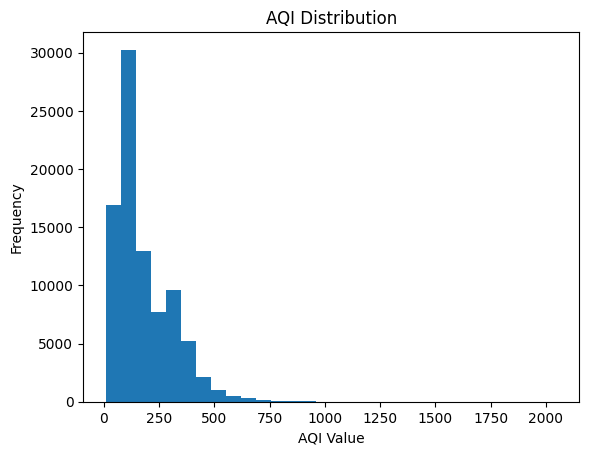

In [ ]:
plt.figure()
plt.hist(data['AQI'], bins=30)
plt.xlabel("AQI Value")
plt.ylabel("Frequency")
plt.title("AQI Distribution")
plt.show()

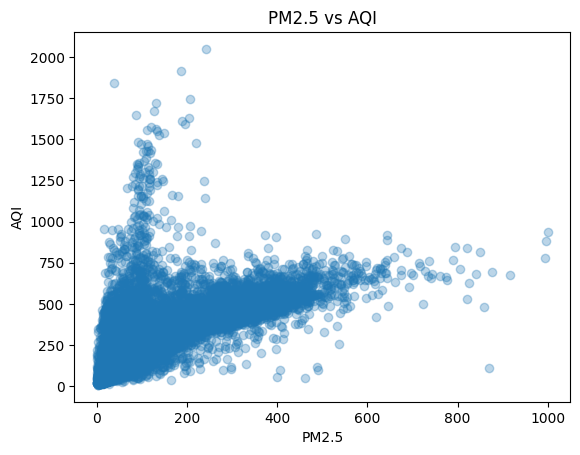

In [ ]:
plt.figure()
plt.scatter(data['PM2.5'], data['AQI'], alpha=0.3)
plt.xlabel("PM2.5")
plt.ylabel("AQI")
plt.title("PM2.5 vs AQI")
plt.show()

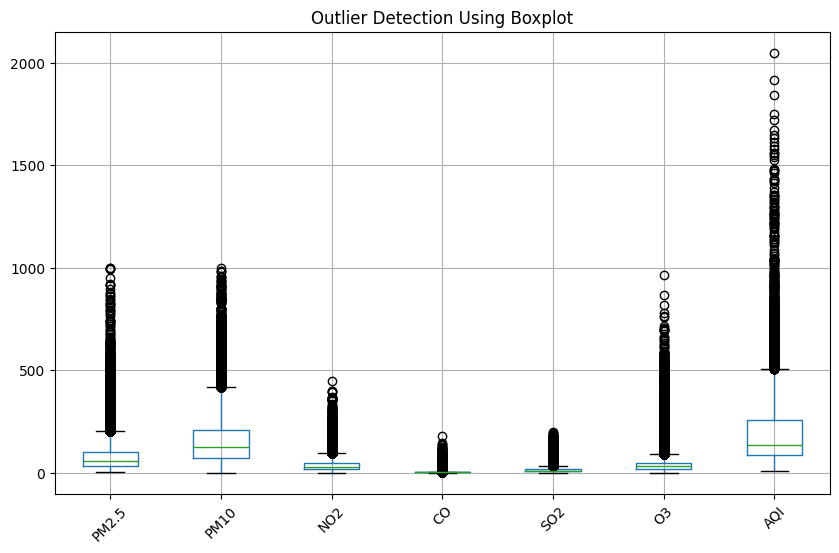

In [ ]:
cols = ['PM2.5','PM10','NO2','CO','SO2','O3','AQI']

plt.figure(figsize=(10,6))
data[cols].boxplot()
plt.xticks(rotation=45)
plt.title("Outlier Detection Using Boxplot")
plt.show()

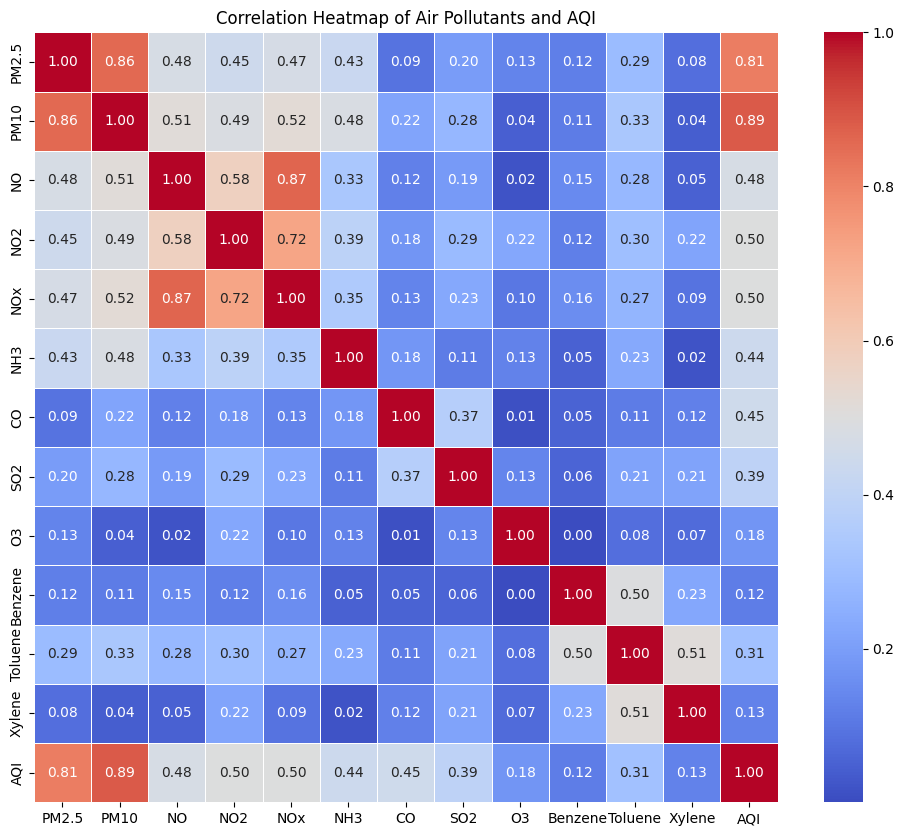

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns (important for correlation)
numeric_data = data.select_dtypes(include=['float64', 'int64'])

# Create correlation matrix
corr_matrix = numeric_data.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Air Pollutants and AQI")
plt.show()

Check Missing Values

In [ ]:
data.isnull().sum()


,0
StationId,0
Date,0
PM2.5,21625
PM10,42706
NO,17106
NO2,16547
NOx,15500
NH3,48105
CO,12998
SO2,25204


**Should we use ALL pollutant columns?**

No.
Because some columns (like Xylene) have too many missing values.

If we try to drop all rows with missing values using all columns →
you’ll lose most of your dataset.

## **SMART COLUMN SELECTION**


**We will use these Columns:**


PM2.5, PM10, NO2, CO, SO2, O3, AQI (target)

These are:

1. Core pollutants

2. Most important for AQI

3. Enough for regression



**We will Ignore:**

City, Date, NH3, NOx, Benzene, Toluene, Xylene, AQI_Bucket

In [ ]:
selected_columns = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3', 'AQI']

data = data[selected_columns]

data.isnull().sum()

,0
PM2.5,21625
PM10,42706
NO2,16547
CO,12998
SO2,25204
O3,25568
AQI,21010


We selected key pollutant features to reduce noise and avoid excessive missing data issues.

## Outliers and Empty Rows Removal

In [ ]:
data.shape

(108035, 7)

In [ ]:
data.select_dtypes(include=['float64','int64']).apply(lambda x: (x == 0).sum())

,0
PM2.5,0
PM10,0
NO2,0
CO,7280
SO2,0
O3,0
AQI,0


In [ ]:
co_zero_rows = data[data['CO'] == 0]

In [ ]:
cols = ['PM2.5','PM10','NO2','SO2','O3','AQI']

co_zero_rows[cols].isnull().sum()

,0
PM2.5,5775
PM10,5942
NO2,5705
SO2,6078
O3,5866
AQI,5751


In [ ]:
data = data[data['CO'] != 0]

print("Shape after removing CO=0 rows:", data.shape)


Shape after removing CO=0 rows: (100755, 7)


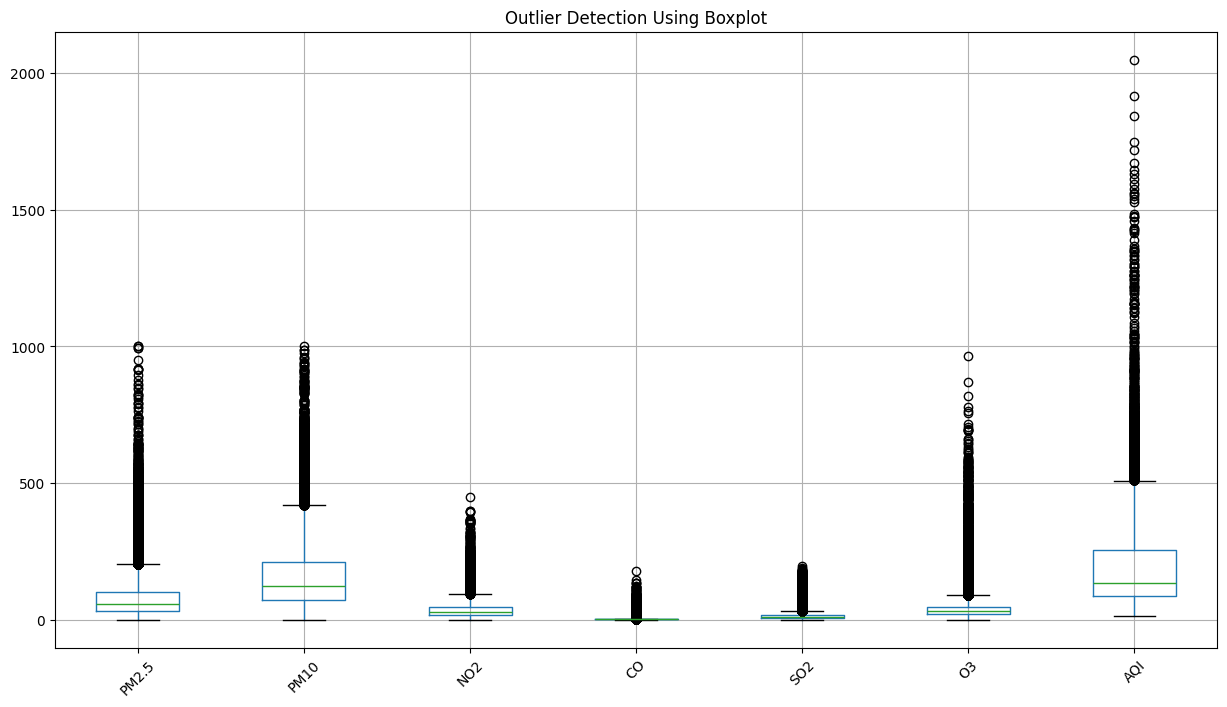

In [ ]:
# List of pollutant columns
cols = ['PM2.5','PM10','NO2','CO','SO2','O3','AQI']

plt.figure(figsize=(15,8))
data[cols].boxplot()
plt.xticks(rotation=45)
plt.title("Outlier Detection Using Boxplot")
plt.show()

## Handling Missing Values

### We will use mean value filling.

We replaced missing values with mean values to maintain dataset size and reduce bias.

In [ ]:
data = data.fillna(data.median())

data.isnull().sum()

,0
PM2.5,0
PM10,0
NO2,0
CO,0
SO2,0
O3,0
AQI,0


In [ ]:
# -------- Feature Engineering --------

# Total Pollution (sum of all pollutants)
data['Total_Pollution'] = (
    data['PM2.5'] +
    data['PM10'] +
    data['NO2'] +
    data['CO'] +
    data['SO2'] +
    data['O3']
)

# PM Ratio
data['PM_Ratio'] = data['PM2.5'] / (data['PM10'] + 1)

# Gas Index
data['Gas_Index'] = (
    data['NO2'] +
    data['CO'] +
    data['SO2'] +
    data['O3']
)

data.head()


,PM2.5,PM10,NO2,CO,SO2,O3,AQI,Total_Pollution,PM_Ratio,Gas_Index
0,71.36,115.75,20.65,0.10,10.76,109.26,133.0,327.88,0.611221,140.77
1,81.40,124.50,20.50,0.12,15.24,127.09,184.0,368.85,0.648606,162.95
2,78.32,129.06,26.00,0.14,26.96,117.44,197.0,377.92,0.602184,170.54
3,88.76,135.32,30.85,0.11,33.59,111.81,198.0,400.44,0.651115,176.36
4,64.18,104.09,28.07,0.09,19.00,138.18,188.0,353.61,0.610715,185.34


## Data Visualization (Exploratory Data Analysis)

1. PM2.5 vs AQI




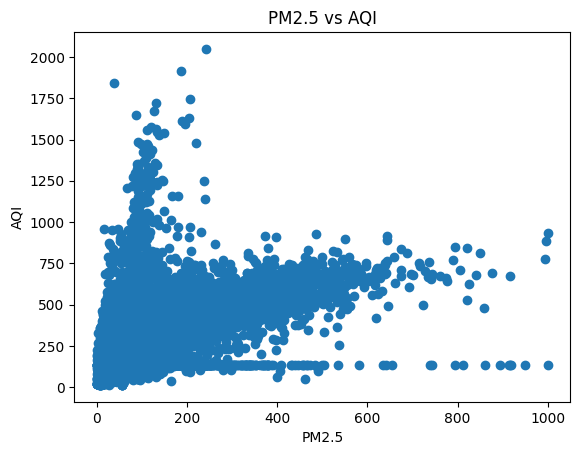

In [ ]:
plt.scatter(data['PM2.5'], data['AQI'])
plt.xlabel("PM2.5")
plt.ylabel("AQI")
plt.title("PM2.5 vs AQI")
plt.show()


PM2.5 shows strong positive relationship with AQI

2. PM10 vs AQI

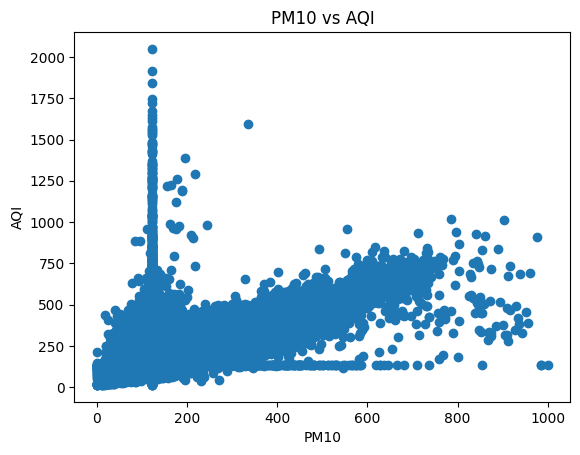

In [ ]:
plt.scatter(data['PM10'], data['AQI'])
plt.xlabel("PM10")
plt.ylabel("AQI")
plt.title("PM10 vs AQI")
plt.show()


PM10 also contributes significantly to AQI, though with more variation.

3. Correlation Heatmap

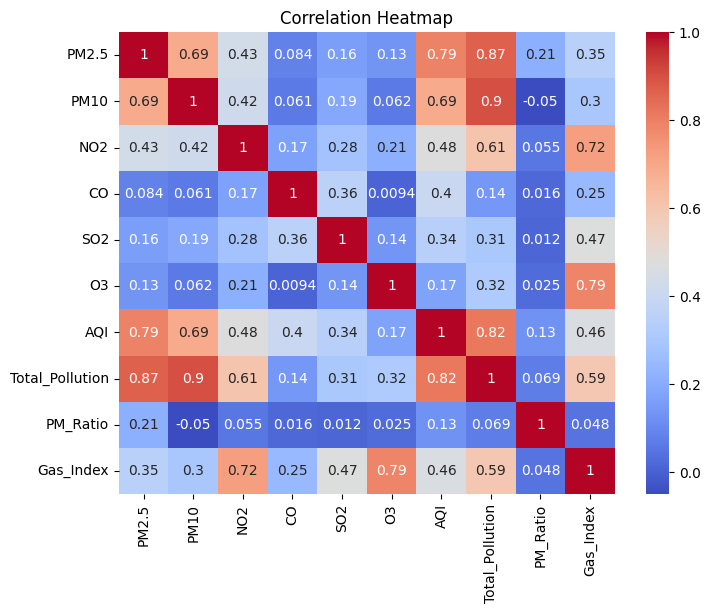

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

✔ CO → strongest (0.65)

✔ PM2.5 → strong (0.63)

✔ NO2 → good (0.52)

✔ O3 → weak (0.19)

Correlation analysis showed that PM2.5, CO, and NO2 have strong influence on AQI.

**We analyzed relationships between pollutants and AQI using visualizations**

**Visualization showed that PM2.5 and PM10 have strong positive correlation with AQI, which supports regression modeling**

## Define Inputs (X) and Output (y)

Now we separate features and target columns

In [ ]:
X = data[
    ['PM2.5','PM10','NO2','CO','SO2','O3',
     'Total_Pollution','PM_Ratio','Gas_Index']
]

y = data['AQI']

# Check shapes
X.shape, y.shape


((100755, 9), (100755,))

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
print(X_scaled[:5])

[[-0.07365074 -0.29369908 -0.49351109 -0.3645223  -0.0757928   2.04509827
   0.11719047  0.04822363  1.02631659]
 [ 0.06800242 -0.20632253 -0.49886557 -0.35979146  0.30583459  2.54840375
   0.33986731  0.08362734  1.43141308]
 [ 0.02454707 -0.16078687 -0.30253445 -0.35506062  1.30419913  2.27600342
   0.38916384  0.03966561  1.57003717]
 [ 0.17184378 -0.09827519 -0.1294061  -0.36215688  1.8689736   2.11707971
   0.51156273  0.0860038   1.67633391]
 [-0.1749525  -0.41013457 -0.22864256 -0.36688773  0.62612902  2.86145241
   0.25703609  0.04774451  1.84034502]]


## Train-Test Split

We will divide the dataset into 80% training and 20% testing to evaluate model performance on unseen data

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y,
    test_size=0.3,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)

# Check split sizes
X_train.shape, X_val.shape, X_test.shape


((70528, 9), (15113, 9), (15114, 9))

## Train the Models





In [ ]:
# Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_val_pred_linear = linear_model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_linear))
print("R2:", r2_score(y_val, y_val_pred_linear))
print("MAE:", mean_absolute_error(y_val, y_val_pred_linear))
print("RMSE:", rmse)


R2: 0.7927418704513086
MAE: 33.721805986954095
RMSE: 55.141561896285275


In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_val_pred_rf = rf_model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_rf))
print("R2:", r2_score(y_val, y_val_pred_rf))
print("MAE:", mean_absolute_error(y_val, y_val_pred_rf))
print("RMSE:", rmse)

R2: 0.879073200568414
MAE: 21.650770543010697
RMSE: 42.11963077736214


In [ ]:
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_val_pred_gb = gb_model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_gb))
print("R2:", r2_score(y_val, y_val_pred_gb))
print("MAE:", mean_absolute_error(y_val, y_val_pred_gb))
print("RMSE:", rmse)

R2: 0.8628628736838593
MAE: 24.867756418843715
RMSE: 44.85396073494819


In [ ]:
knn_model = KNeighborsRegressor(
    n_neighbors=7,
    weights='distance'
)

knn_model.fit(X_train, y_train)

y_val_pred_knn = knn_model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_knn))
print("R2:", r2_score(y_val, y_val_pred_knn))
print("MAE:", mean_absolute_error(y_val, y_val_pred_knn))
print("RMSE:", rmse)

R2: 0.8660855913880774
MAE: 23.567896185475874
RMSE: 44.323794234654706


When we train:

✔ Data is given

✔ Formula is learned

✔ Weights are calculated

✔ Error is minimized

✔ Model is ready to predict

Validation Predictions

In [ ]:
# ---- Linear Regression ----
print("\n---- Linear Regression ----")
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_linear))
print("R2:", r2_score(y_val, y_val_pred_linear))
print("MAE:", mean_absolute_error(y_val, y_val_pred_linear))
print("RMSE:", rmse)

# ---- Random Forest ----
print("\n---- Random Forest ----")
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_rf))
print("R2:", r2_score(y_val, y_val_pred_rf))
print("MAE:", mean_absolute_error(y_val, y_val_pred_rf))
print("RMSE:", rmse)

# ---- KNN ----
print("\n---- KNN ----")
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_knn))
print("R2:", r2_score(y_val, y_val_pred_knn))
print("MAE:", mean_absolute_error(y_val, y_val_pred_knn))
print("RMSE:", rmse)

# ---- Gradient Boosting ----
print("\n---- Gradient Boosting ----")
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_gb))
print("R2:", r2_score(y_val, y_val_pred_gb))
print("MAE:", mean_absolute_error(y_val, y_val_pred_gb))
print("RMSE:", rmse)


---- Linear Regression ----
R2: 0.7927418704513086
MAE: 33.721805986954095
RMSE: 55.141561896285275

---- Random Forest ----
R2: 0.879073200568414
MAE: 21.650770543010697
RMSE: 42.11963077736214

---- KNN ----
R2: 0.8660855913880774
MAE: 23.567896185475874
RMSE: 44.323794234654706

---- Gradient Boosting ----
R2: 0.8628628736838593
MAE: 24.867756418843715
RMSE: 44.85396073494819


# Tuning Random Forest


In [ ]:
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_random = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=25,          # tries 25 combinations
    cv=3,               # 3-fold cross validation
    scoring='r2',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [ ]:
rf_random.fit(X_train, y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


RandomizedSearchCV(cv=3,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30, 40],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 400]},
                   random_state=42, scoring='r2', verbose=2)

In [ ]:
print("Best Parameters:")
print(rf_random.best_params_)

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}


In [ ]:
best_rf = rf_random.best_estimator_

best_rf.fit(X_train, y_train)

RandomForestRegressor(max_features='log2', min_samples_split=5,
                      n_estimators=300, n_jobs=-1, random_state=42)

In [ ]:
# Validation Prediction
y_val_pred_rf_tuned = best_rf.predict(X_val)

print("----- Tuned RF Validation Performance -----")
print("R2:", r2_score(y_val, y_val_pred_rf_tuned))
print("MAE:", mean_absolute_error(y_val, y_val_pred_rf_tuned))

----- Tuned RF Validation Performance -----
R2: 0.8874221990642288
MAE: 21.23427360766621


In [ ]:
# Predicted classes
y_val_pred_class_rf_tuned = pd.Series(y_val_pred_rf_tuned).apply(aqi_category)

print("----- Tuned RF Classification Report (Validation) -----")
print(classification_report(y_val_class, y_val_pred_class_rf_tuned))

----- Tuned RF Classification Report (Validation) -----
              precision    recall  f1-score   support

        Good       0.87      0.47      0.61       818
    Moderate       0.83      0.87      0.85      6474
        Poor       0.61      0.70      0.65      1738
Satisfactory       0.76      0.77      0.77      3582
      Severe       0.85      0.75      0.79       759
   Very Poor       0.76      0.71      0.73      1742

    accuracy                           0.78     15113
   macro avg       0.78      0.71      0.73     15113
weighted avg       0.78      0.78      0.78     15113



# Saving Trained Models


In [ ]:
save_path = "/content/drive/MyDrive/AI_Project/models/best_random_forest_model.pkl"
joblib.dump(best_rf, save_path)
print("Model saved to Google Drive!")
scaler_path = "/content/drive/MyDrive/AI_Project/models/scaler.pkl"

joblib.dump(scaler, scaler_path)

print("Scaler saved to Google Drive!")

Model saved to Google Drive!
Scaler saved to Google Drive!


In [ ]:
best_rf = joblib.load("/content/drive/MyDrive/AI_Project/models/best_random_forest_model.pkl")
scaler = joblib.load("/content/drive/MyDrive/AI_Project/models/scaler.pkl")


## Prediction & Evaluation

Now that the model is trained:

* We give it new data (X_test)

* It predicts AQI

* We compare it with real AQI (y_test)

* We measure the error


### PART A :  Make Predictions

In [ ]:
y_pred_best_rf = best_rf.predict(X_test)


### PART B : Evaluate Performance

In [ ]:
print("\n----- Random Forest Regression -----")
print("R2:", r2_score(y_test, y_pred_best_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_best_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best_rf)))



----- Random Forest Regression -----
R2: 0.8874640420338679
MAE: 21.806660639999897
RMSE: 41.39128045876112


### PART C : Visual Check

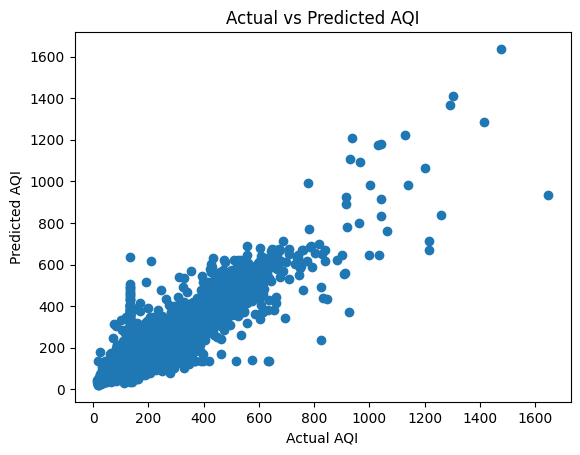

In [ ]:
plt.scatter(y_test, y_pred_best_rf)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI")
plt.show()


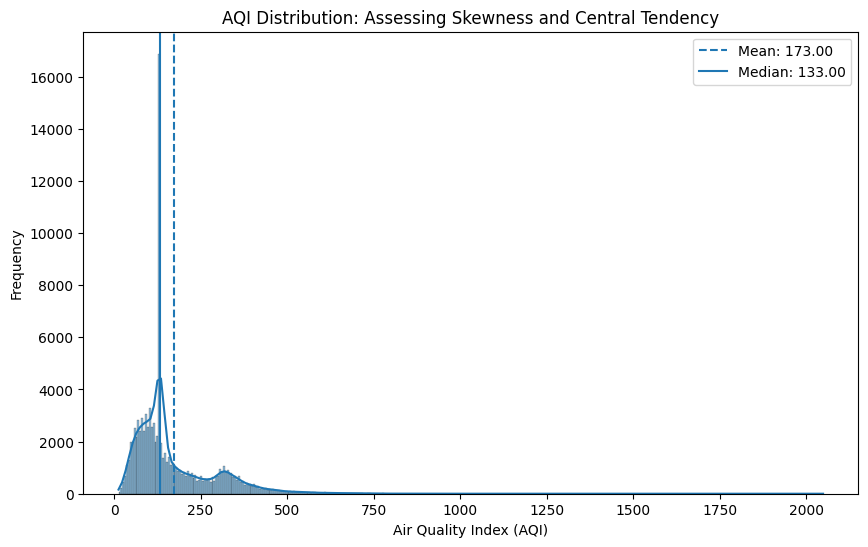

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data['AQI'], kde=True)
plt.axvline(data['AQI'].mean(), linestyle='--', label=f'Mean: {data["AQI"].mean():.2f}')
plt.axvline(data['AQI'].median(), linestyle='-', label=f'Median: {data["AQI"].median():.2f}')
plt.title('AQI Distribution: Assessing Skewness and Central Tendency')
plt.xlabel('Air Quality Index (AQI)')
plt.ylabel('Frequency')
plt.legend()
plt.show()
# Insight: Shows if the dataset is dominated by "Good" or "Hazardous" days.

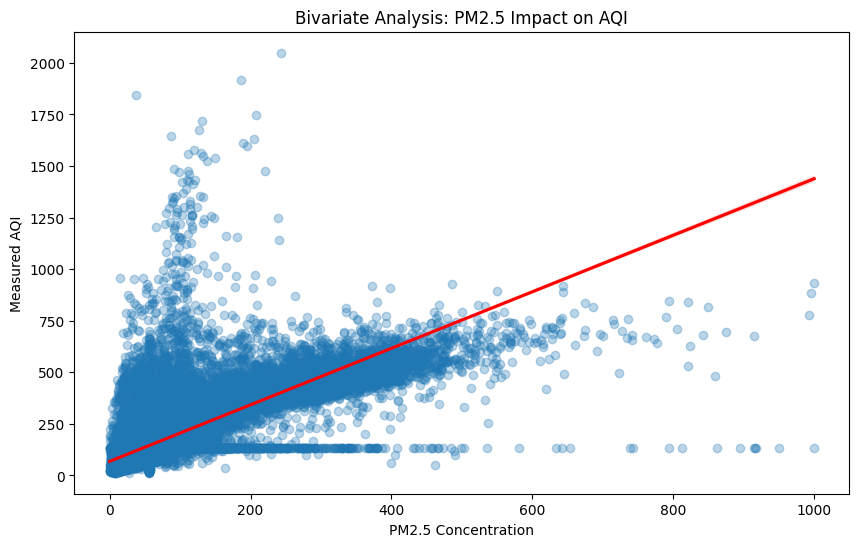

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x='PM2.5', y='AQI', data=data, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Bivariate Analysis: PM2.5 Impact on AQI')
plt.xlabel('PM2.5 Concentration')
plt.ylabel('Measured AQI')
plt.show()

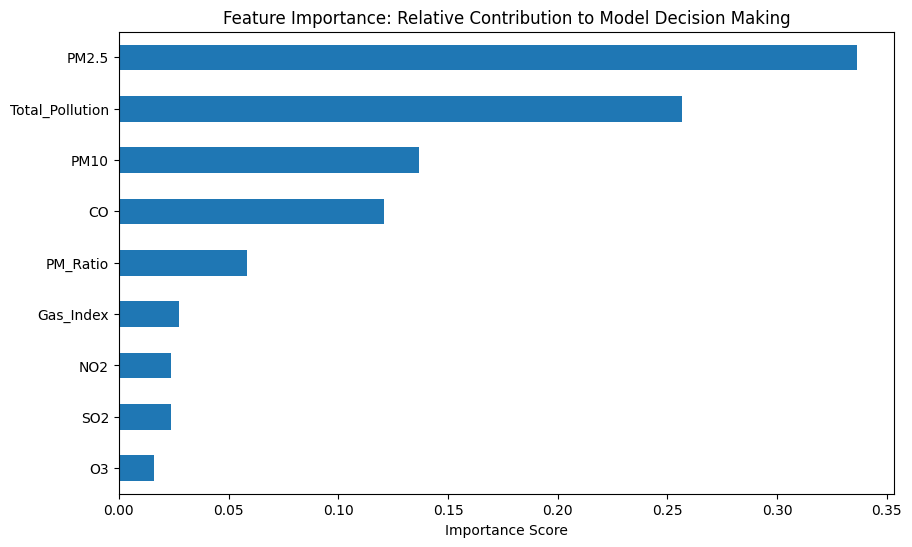

In [ ]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
importances.plot(kind='barh')
plt.title('Feature Importance: Relative Contribution to Model Decision Making')
plt.xlabel('Importance Score')
plt.show()

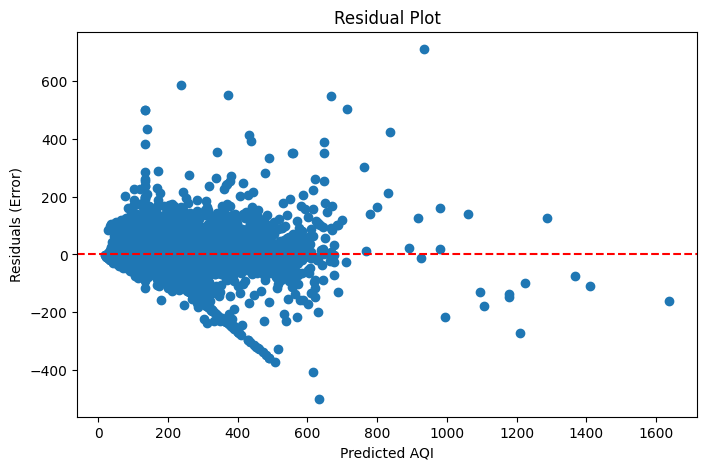

In [ ]:
residuals = y_test - y_pred_best_rf

plt.figure(figsize=(8,5))
plt.scatter(y_pred_best_rf, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted AQI")
plt.ylabel("Residuals (Error)")
plt.title("Residual Plot")
plt.show()

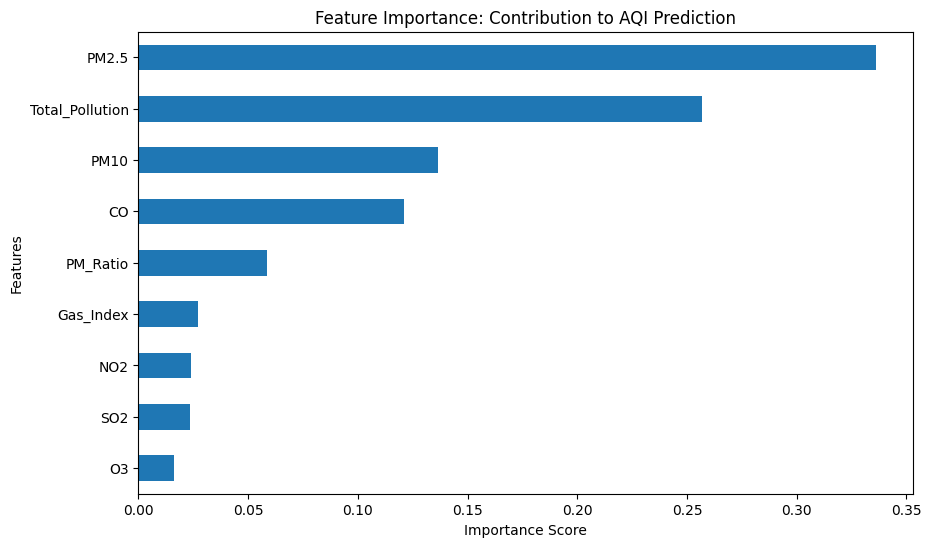

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importances = pd.Series(
    best_rf.feature_importances_,
    index = X.columns
).sort_values(ascending=True)

# Plot
plt.figure(figsize=(10,6))
importances.plot(kind='barh')
plt.title("Feature Importance: Contribution to AQI Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

We evaluated the model using MAE, MSE, and R² score, and visualized actual vs predicted AQI to verify accuracy